In [1]:
import anndata as a
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

In [2]:
mpl.rcParams["figure.figsize"] = (5, 5)
mpl.rcParams['pdf.fonttype'] = 42

In [3]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/ascites_malignant-cells_no-CD14_primary-tumor.h5ad')
adata

AnnData object with n_obs × n_vars = 9707 × 2000
    obs: 'AC3', 'ClusterID', 'ClusterName', 'OC2', 'OPC_shared4', 'OPC_variable5', 'SCT_snn_res_0_5', 'cellcycle1', 'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 'orig_ident', 'percent_mt', 'seurat_clusters', 'sample_batch', 'Clusters', '_X', '_Y', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Selected', 'sct_detection_rate', 'sct_gmean', 'sct_residual_mean', 'sct_residual_variance', 'sct_variable', 'sct_variance', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm'
    uns: 'neighbors', 'pca'
    obsm: 'X_pca', 'mnn_cell_embeddings', 'umap_cell_embeddings'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'norm_data', 'scale_data', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

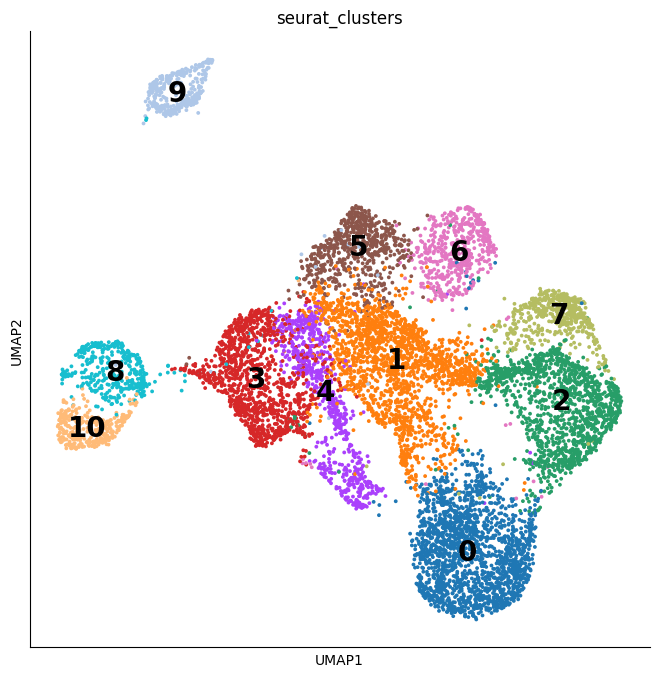

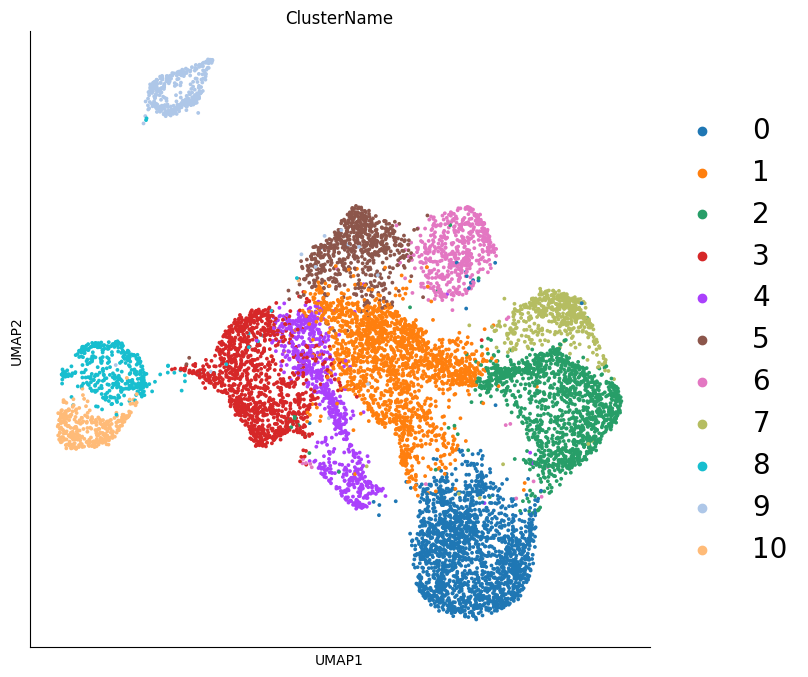

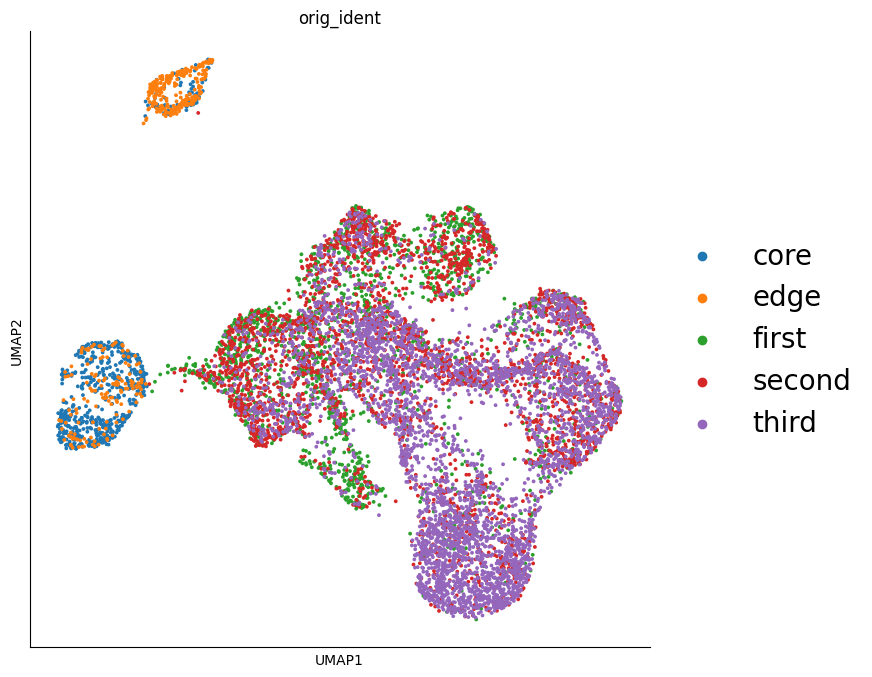

In [15]:
adata.obsm['X_umap'] = adata.obsm['umap_cell_embeddings']

# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata, color=['seurat_clusters'], size=30,
               color_map = 'RdPu', ncols = 2, legend_loc='on data',
               legend_fontsize=20)
    sc.pl.umap(adata, color=['ClusterName'], size=30,
               color_map = 'RdPu', ncols = 2,
               legend_fontsize=20)
    sc.pl.umap(adata, color=['orig_ident'], size=30,
               color_map = 'RdPu', ncols = 2,
               legend_fontsize=20)

In [4]:
sc.tl.diffmap(adata)

In [6]:
adata

AnnData object with n_obs × n_vars = 9707 × 2000
    obs: 'AC3', 'ClusterID', 'ClusterName', 'OC2', 'OPC_shared4', 'OPC_variable5', 'SCT_snn_res_0_5', 'cellcycle1', 'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 'orig_ident', 'percent_mt', 'seurat_clusters', 'sample_batch', 'Clusters', '_X', '_Y', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Selected', 'sct_detection_rate', 'sct_gmean', 'sct_residual_mean', 'sct_residual_variance', 'sct_variable', 'sct_variance', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm'
    uns: 'neighbors', 'pca', 'diffmap_evals'
    obsm: 'X_pca', 'mnn_cell_embeddings', 'umap_cell_embeddings', 'X_diffmap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'norm_data', 'scale_data', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

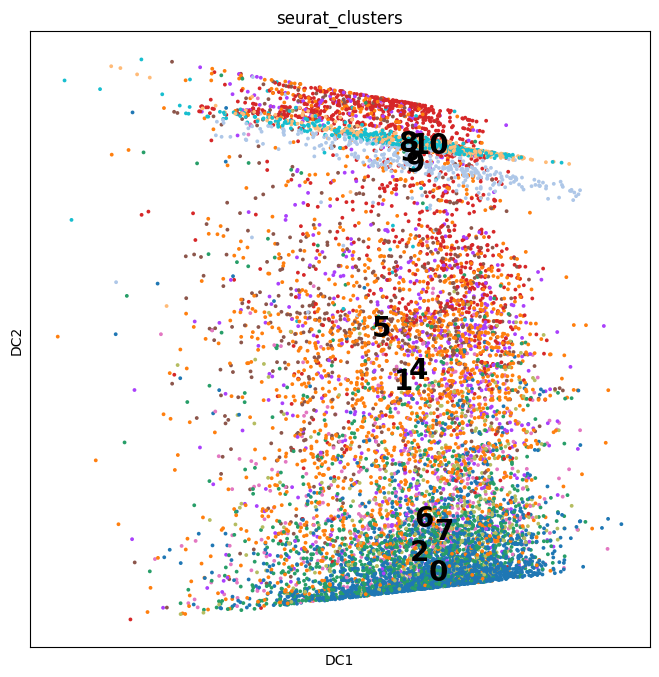

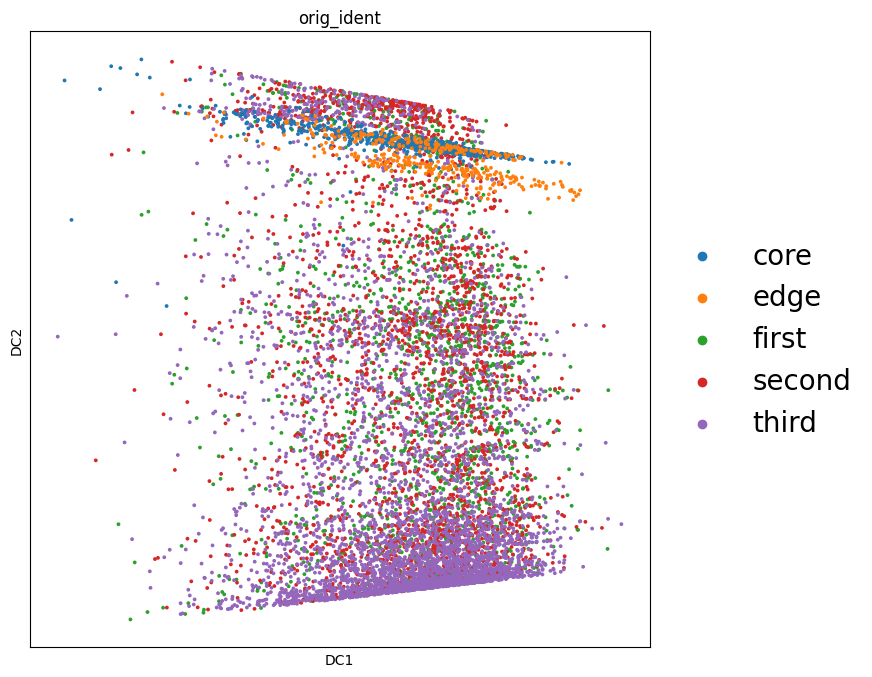

In [8]:
# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.diffmap(adata, color=['seurat_clusters'], 
                  size=30,
                  legend_loc='on data',
               legend_fontsize=20)
    sc.pl.diffmap(adata, color=['orig_ident'], 
                  size=30,
               legend_fontsize=20)

In [6]:
print(adata.X)

  (0, 0)	0.7738571763038635
  (0, 19)	0.7738571763038635
  (0, 21)	0.7738571763038635
  (0, 36)	0.7738571763038635
  (0, 57)	0.7738571763038635
  (0, 98)	0.7738571763038635
  (0, 111)	0.7738571763038635
  (0, 114)	1.547714352607727
  (0, 120)	0.7738571763038635
  (0, 131)	1.547714352607727
  (0, 144)	0.7738571763038635
  (0, 147)	0.7738571763038635
  (0, 160)	0.7738571763038635
  (0, 161)	0.7738571763038635
  (0, 166)	0.7738571763038635
  (0, 197)	0.7738571763038635
  (0, 203)	0.7738571763038635
  (0, 206)	0.7738571763038635
  (0, 209)	0.7738571763038635
  (0, 217)	0.7738571763038635
  (0, 226)	0.7738571763038635
  (0, 234)	1.547714352607727
  (0, 266)	0.7738571763038635
  (0, 280)	0.7738571763038635
  (0, 300)	0.7738571763038635
  :	:
  (9706, 1942)	13.784995079040527
  (9706, 1946)	27.569990158081055
  (9706, 1950)	13.784995079040527
  (9706, 1951)	68.92497253417969
  (9706, 1953)	124.06495666503906
  (9706, 1956)	41.354984283447266
  (9706, 1957)	13.784995079040527
  (9706, 1958)	13

In [15]:
sc.external.tl.phate(adata)

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/phate/phate.py:186: FutureWarning: k is deprecated. Please use knn in future.
  warnings.warn("k is deprecated. Please use knn in future.", FutureWarning)
/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/phate/phate.py:190: FutureWarning: a is deprecated. Please use decay in future.
  warnings.warn("a is deprecated. Please use decay in future.", FutureWarning)


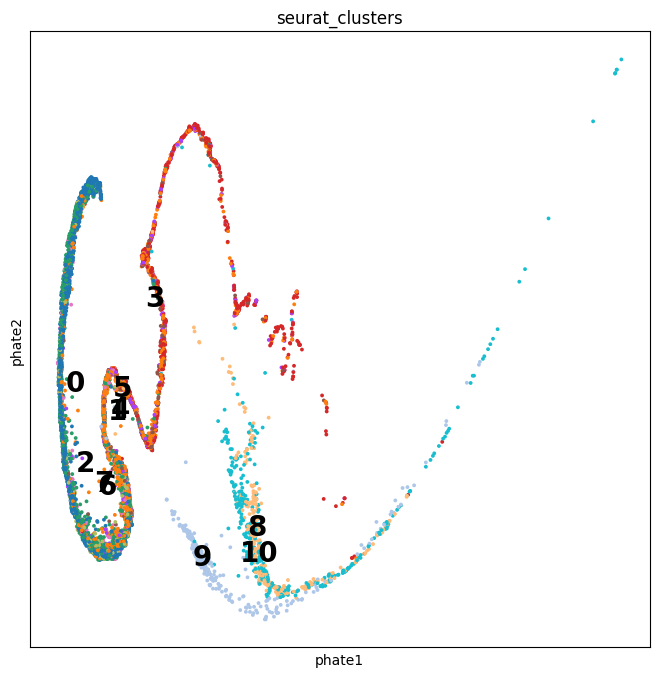

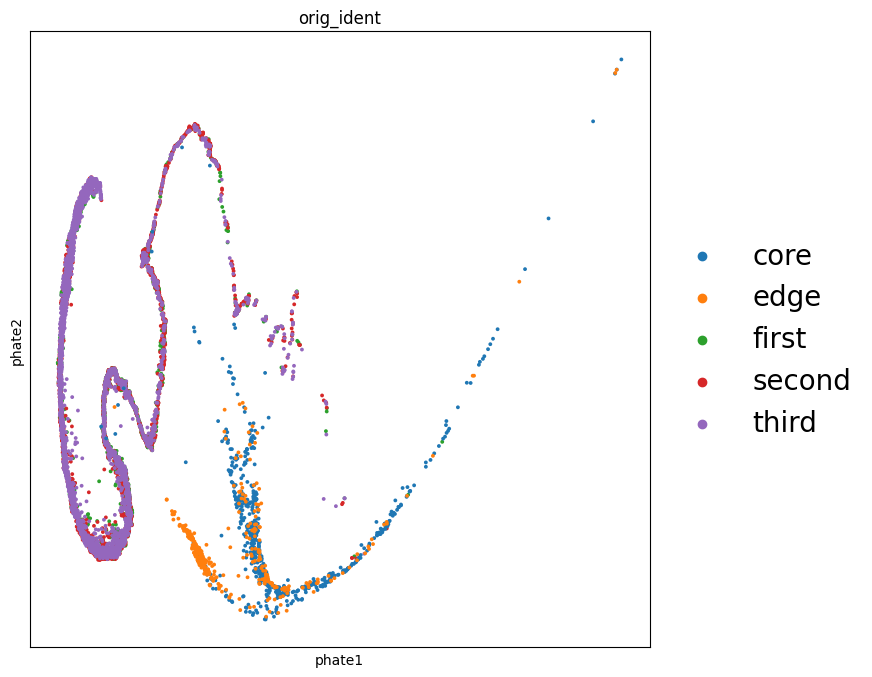

In [16]:
# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.external.pl.phate(adata, color=['seurat_clusters'], size=30,
               color_map = 'RdPu', legend_loc='on data',
               legend_fontsize=20)
    sc.external.pl.phate(adata, color=['orig_ident'], size=30,
               color_map = 'RdPu', 
               legend_fontsize=20)

In [10]:
import palantir

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

In [11]:
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5)

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
ms_data = palantir.utils.determine_multiscale_space(adata)

In [13]:
imputed_X = palantir.utils.run_magic_imputation(adata)

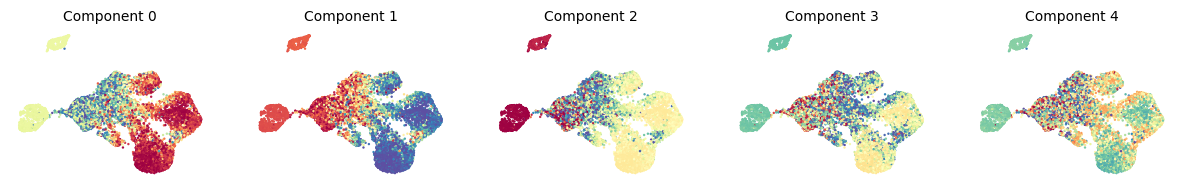

In [16]:
palantir.plot.plot_diffusion_components(adata)
plt.show()

In [19]:
# Assuming 'adata' is your AnnData object
# List of clusters to sample from
clusters_of_interest = [8, 0, 2]

# Initialize an empty dictionary to store results
random_obs_names = {}

# Iterate through each cluster and select a random observation name
for cluster in clusters_of_interest:
    # Subset the AnnData object for the current cluster
    cluster_cells = adata.obs[adata.obs['ClusterID'] == cluster]
    
    # Randomly select one obs_name
    if not cluster_cells.empty:
        random_obs_name = np.random.choice(cluster_cells.index, size=1, replace=False)[0]
        random_obs_names[cluster] = random_obs_name
    else:
        random_obs_names[cluster] = None  # Handle cases where no cells exist for the cluster

# Print or return the dictionary of random obs_names
print(random_obs_names)

{8: 'ACTATTCGTGTTACTG', 0: None, 2: 'GCCAGCAAGGTAAAGG'}


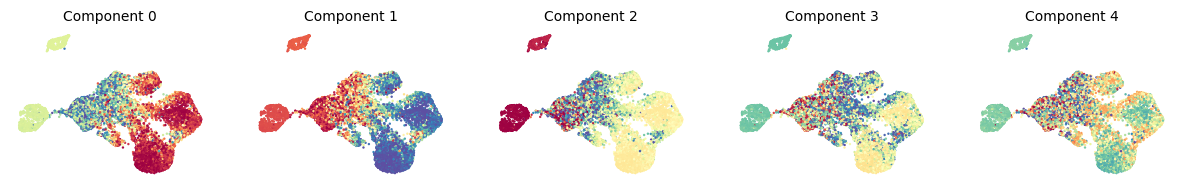

In [23]:
palantir.plot.plot_diffusion_components(adata)
plt.show()

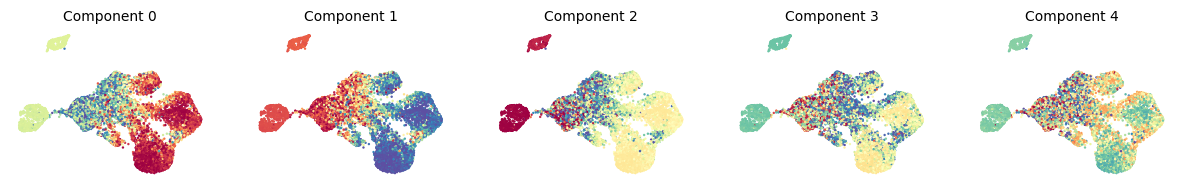

In [23]:
palantir.plot.plot_diffusion_components(adata,embedding_basis)
plt.show()

In [9]:
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

NameError: name 'palantir' is not defined